In [27]:
import pandas as pd

# Load Dataset
df = pd.read_csv("../data/placement.csv")

In [28]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [29]:
df

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57
...,...,...
195,6.93,2.46
196,5.89,2.57
197,7.21,3.24
198,7.63,3.96


In [30]:
df.shape

(200, 2)

In [31]:
df.shape[0]

200

In [32]:
df.shape[1]

2

In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   cgpa     200 non-null    float64
 1   package  200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [34]:
df.describe()

,cgpa,package
count,200.000000,200.000000
mean,6.990500,2.996050
std,1.069409,0.691644
min,4.260000,1.370000
25%,6.190000,2.487500
50%,6.965000,2.995000
75%,7.737500,3.492500
max,9.580000,4.620000


In [35]:
import matplotlib.pyplot as plt

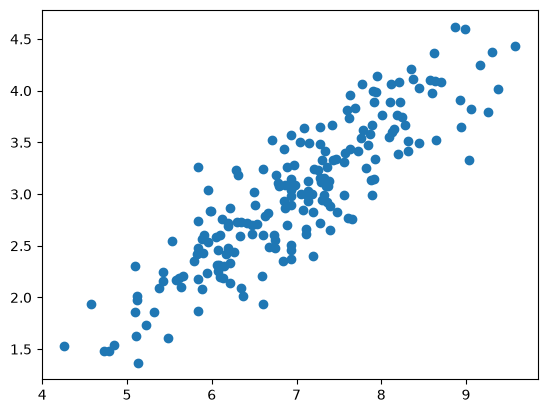

In [36]:
plt.scatter(df['cgpa'], df['package'])

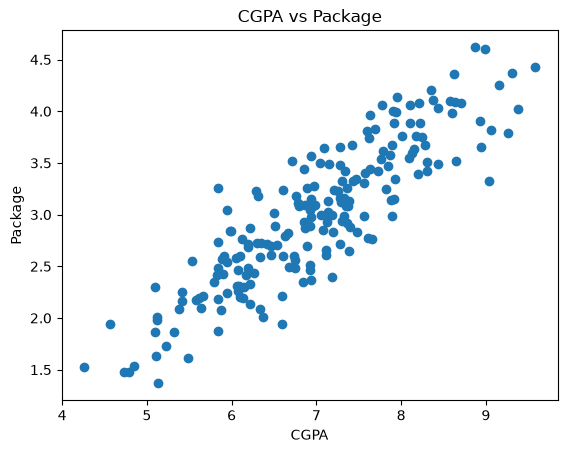

In [37]:
plt.xlabel('CGPA')
plt.ylabel('Package')
plt.title('CGPA vs Package')
plt.scatter(df['cgpa'], df['package'])
plt.show()

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [39]:
X = df[['cgpa']]

In [40]:
X

,cgpa
0,6.89
1,5.12
2,7.82
3,7.42
4,6.94
...,...
195,6.93
196,5.89
197,7.21
198,7.63


In [41]:
y = df['package']

In [42]:
y

0      3.26
1      1.98
2      3.25
3      3.67
4      3.57
       ... 
195    2.46
196    2.57
197    3.24
198    3.96
199    2.33
Name: package, Length: 200, dtype: float64

In [43]:
print(X.shape)
print(y.shape)

(200, 1)
(200,)


In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,
                                                    random_state=42)

In [45]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(160, 1)
(40, 1)
(160,)
(40,)


In [46]:
model = LinearRegression()

In [47]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.57]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['cgpa']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.027
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [48]:
y_pred = model.predict(X_test)

print(y_pred)

[2.78031348 3.13635249 3.1995207  2.38981908 3.52684689 3.76803461
 3.16506531 2.54486832 3.17655044 3.4923915  1.90744364 2.34962112
 3.6876387  2.75734322 3.47516381 3.04447145 2.32665086 3.20526327
 2.17734418 3.314372   2.45298729 2.90090734 3.32011456 2.87219451
 3.33734226 2.19457187 1.41932564 2.7114027  3.18229301 2.32665086
 3.74506435 2.95833298 3.68189614 2.97556068 2.59080884 3.34882738
 2.47595755 3.07318428 4.17575671 2.95833298]


In [49]:
print(y_pred.shape)

(40,)


In [52]:
comparison = pd.DataFrame({
    'Actual Values': y_test.values,
    'Predicted Values': y_pred
})

print(comparison)

    Actual Values  Predicted Values
0            2.79          2.780313
1            3.23          3.136352
2            3.26          3.199521
3            3.04          2.389819
4            3.34          3.526847
5            4.21          3.768035
6            2.94          3.165065
7            2.87          2.544868
8            2.99          3.176550
9            3.58          3.492392
10           1.63          1.907444
11           2.08          2.349621
12           4.08          3.687639
13           2.21          2.757343
14           3.47          3.475164
15           3.64          3.044471
16           2.74          2.326651
17           3.08          3.205263
18           2.17          2.177344
19           2.99          3.314372
20           2.31          2.452987
21           2.35          2.900907
22           3.40          3.320115
23           3.08          2.872195
24           3.81          3.337342
25           2.19          2.194572
26           1.53          1

In [53]:
comparison['Error']=comparison['Actual Values']-comparison['Predicted Values']

print(comparison)

    Actual Values  Predicted Values     Error
0            2.79          2.780313  0.009687
1            3.23          3.136352  0.093648
2            3.26          3.199521  0.060479
3            3.04          2.389819  0.650181
4            3.34          3.526847 -0.186847
5            4.21          3.768035  0.441965
6            2.94          3.165065 -0.225065
7            2.87          2.544868  0.325132
8            2.99          3.176550 -0.186550
9            3.58          3.492392  0.087608
10           1.63          1.907444 -0.277444
11           2.08          2.349621 -0.269621
12           4.08          3.687639  0.392361
13           2.21          2.757343 -0.547343
14           3.47          3.475164 -0.005164
15           3.64          3.044471  0.595529
16           2.74          2.326651  0.413349
17           3.08          3.205263 -0.125263
18           2.17          2.177344 -0.007344
19           2.99          3.314372 -0.324372
20           2.31          2.45298

In [54]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [55]:
# Calculate Mean Absolute Error (MAE)
# But first we need to find Absolute Error.
comparison['Absolute Error']= comparison['Error'].abs()
print (comparison)

    Actual Values  Predicted Values     Error  Absolute Error
0            2.79          2.780313  0.009687        0.009687
1            3.23          3.136352  0.093648        0.093648
2            3.26          3.199521  0.060479        0.060479
3            3.04          2.389819  0.650181        0.650181
4            3.34          3.526847 -0.186847        0.186847
5            4.21          3.768035  0.441965        0.441965
6            2.94          3.165065 -0.225065        0.225065
7            2.87          2.544868  0.325132        0.325132
8            2.99          3.176550 -0.186550        0.186550
9            3.58          3.492392  0.087608        0.087608
10           1.63          1.907444 -0.277444        0.277444
11           2.08          2.349621 -0.269621        0.269621
12           4.08          3.687639  0.392361        0.392361
13           2.21          2.757343 -0.547343        0.547343
14           3.47          3.475164 -0.005164        0.005164
15      

In [61]:
# Since we have Absolute Error now
mae = comparison['Absolute Error'].mean()

print(mae)

0.23150985393278373


In [60]:
# Calculate Mean Squared Error.
comparison['Squared Error']=comparison['Absolute Error']**2

print(comparison)

    Actual Values  Predicted Values     Error  Absolute Error  Squared Error
0            2.79          2.780313  0.009687        0.009687       0.000094
1            3.23          3.136352  0.093648        0.093648       0.008770
2            3.26          3.199521  0.060479        0.060479       0.003658
3            3.04          2.389819  0.650181        0.650181       0.422735
4            3.34          3.526847 -0.186847        0.186847       0.034912
5            4.21          3.768035  0.441965        0.441965       0.195333
6            2.94          3.165065 -0.225065        0.225065       0.050654
7            2.87          2.544868  0.325132        0.325132       0.105711
8            2.99          3.176550 -0.186550        0.186550       0.034801
9            3.58          3.492392  0.087608        0.087608       0.007675
10           1.63          1.907444 -0.277444        0.277444       0.076975
11           2.08          2.349621 -0.269621        0.269621       0.072696

In [63]:
# since we have squared error now so
mse=comparison['Squared Error'].mean()

print(mse)

0.08417638361329657


In [64]:
# calculate Root Mean Squared Error RMSE
rmse = mse ** 0.5

print(rmse)

0.2901316659954521


In [65]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_sklearn = mean_absolute_error(y_test, y_pred)
mse_sklearn = mean_squared_error(y_test, y_pred)
rmse_sklearn = mse_sklearn ** 0.5

print("MAE is : ", mae_sklearn)
print("MSE is : ", mse_sklearn)
print("RMSE is : ", rmse_sklearn)

MAE is :  0.23150985393278373
MSE is :  0.08417638361329657
RMSE is :  0.2901316659954521


In [66]:
diff_in_MAE=mae-mae_sklearn
print(diff_in_MAE)

0.0


# R² Score (Coefficient of Determination)

## Understanding R² with a Tiny Example

Before calculating R² on our real CGPA vs Package dataset, we will
calculate it manually on a tiny dataset.

The purpose is to understand:

- Mean / baseline prediction
- SST — Total Sum of Squares
- SSE — Sum of Squared Errors
- R² — Coefficient of Determination


In [67]:
actual = [10, 20, 30, 40]
predicted = [11, 18, 31, 39]

In [68]:
import numpy as np

mean = np.mean(actual)

print(mean)

25.0


In [69]:
sst = sum((y - mean) ** 2 for y in actual)

print(sst)

500.0


In [70]:
sse = sum((y - y_pred) ** 2 for y, y_pred in zip(actual, predicted))

print(sse)

7


In [71]:
r2 = 1 - (sse / sst)

print(r2)

0.986


# R² Score : CGPA vs Package Model

> **Purpose:** Apply everything we learned in the tiny example to our actual Linear Regression model.
>
> Here we will:
> - Calculate SST using `y_test`
> - Calculate SSE using `y_test` and `y_pred`
> - Calculate R² manually
> - Calculate R² using `sklearn`
> - Compare both results
> - Interpret the `R²` of our actual model
>
> **This is the actual evaluation of our CGPA → Package Linear Regression model.**



In [73]:
# Calculate Mean of Actual Values
y_mean = y_test.mean()

print("Mean of y_test:", y_mean)

Mean of y_test: 2.99675


In [74]:
sst = sum((y - y_mean) ** 2 for y in y_test)

print("SST:", sst)

SST: 14.839277500000003


In [76]:
sse = sum((y - y_pred_value) ** 2 for y, y_pred_value in zip
          (y_test, y_pred))

print("SSE:", sse)

SSE: 3.3670553445318623


In [79]:
# Manual Calculation of R2 score will be:
r2_manual = 1 - (sse / sst)

print("Manual R²:", r2_manual)

Manual R²: 0.7730984312051674


In [80]:
from sklearn.metrics import r2_score

In [81]:
r2_sklearn = r2_score(y_test, y_pred)

print("Sklearn R² score will be :", r2_sklearn)

Sklearn R² score will be : 0.7730984312051673


In [82]:
difference = r2_manual - r2_sklearn

print("Difference:", difference)

Difference: 1.1102230246251565e-16


In [83]:
r2 = r2_sklearn
n = len(y_test)
k = X_test.shape[1]

adjusted_r2 = 1 - ((1 - r2) * (n - 1)) / (n - 1 - k)

print("R²:", r2)
print("n:", n)
print("k:", k)
print("Adjusted R² score will be :", adjusted_r2)

R²: 0.7730984312051673
n: 40
k: 1
Adjusted R² score will be : 0.7671273372895138
